# Assignment 9: Feature Importance Visualization and Interpretation

**Course:** Tata Technologies TechPulse Applied AI/ML  
**Topic:** Model Interpretability & Feature Engineering  
**Model:** Random Forest Regressor & Permutation Importance  
**Dataset:** Synthetic Automotive Resale Pricing Dataset (600 records, 7 features)  

--- 

## 1. Aim and Objectives
- Quantify and visualize feature importance for an automotive resale pricing regression problem.
- Train a `RandomForestRegressor` and extract Random Forest Mean Decrease in Impurity (MDI) `feature_importances_`.
- Compute out-of-sample `permutation_importance` to validate feature reliance on unseen test data.
- Create sorted horizontal bar chart visualizers comparing relative feature contributions.
- Interpret which vehicle attributes drive resale price predictions while establishing that correlation/importance does not imply causation.

## 2. Import Libraries & Set Reproducibility Seed
Import Scikit-Learn, Pandas, NumPy, Matplotlib, and Seaborn.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Set seed for reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Generate Automotive Dataset
We construct a synthetic automotive dataset with 600 records containing numerical and categorical features:
- `age_years`: Vehicle age in years (1 - 15)
- `mileage_km`: Total distance driven in kilometers (5,000 - 200,000 km)
- `engine_size_L`: Engine displacement in liters (1.0 - 4.5 L)
- `horsepower`: Engine power in HP (80 - 400 HP)
- `fuel_efficiency_kmpl`: Fuel efficiency in km/L (8.0 - 25.0 km/L)
- `vehicle_weight_kg`: Curb weight in kg (900 - 2500 kg)
- `brand`: Car manufacturer (`Toyota`, `Honda`, `Ford`, `BMW`, `Hyundai`)
- **Target (`price`):** Resale price in USD.

In [2]:
n_samples = 600

age_years = np.random.uniform(1, 15, n_samples)
mileage_km = age_years * np.random.uniform(10000, 18000, n_samples) + np.random.normal(0, 2000, n_samples)
mileage_km = np.clip(mileage_km, 5000, 250000)
engine_size_L = np.random.uniform(1.0, 4.5, n_samples)
horsepower = engine_size_L * np.random.uniform(60, 90, n_samples) + np.random.normal(0, 10, n_samples)
fuel_efficiency_kmpl = 30.0 - (engine_size_L * 4.0) + np.random.normal(0, 1.5, n_samples)
vehicle_weight_kg = 1000 + (engine_size_L * 300) + np.random.normal(0, 50, n_samples)
brands = np.random.choice(['Toyota', 'Honda', 'Ford', 'BMW', 'Hyundai'], size=n_samples, p=[0.25, 0.25, 0.20, 0.15, 0.15])

brand_premium = {'BMW': 12000, 'Toyota': 3000, 'Honda': 2500, 'Ford': 1000, 'Hyundai': 0}
premium_values = np.array([brand_premium[b] for b in brands])

# Target formula
price = (
    35000
    - (age_years * 1800)
    - (mileage_km * 0.08)
    + (horsepower * 80)
    + (fuel_efficiency_kmpl * 250)
    + premium_values
    + np.random.normal(0, 1200, n_samples)
)
price = np.clip(price, 2000, 85000)

df = pd.DataFrame({
    'brand': brands,
    'age_years': np.round(age_years, 1),
    'mileage_km': np.round(mileage_km, 0),
    'engine_size_L': np.round(engine_size_L, 2),
    'horsepower': np.round(horsepower, 1),
    'fuel_efficiency_kmpl': np.round(fuel_efficiency_kmpl, 1),
    'vehicle_weight_kg': np.round(vehicle_weight_kg, 0),
    'price': np.round(price, 2)
})

print(f"Dataset generated successfully ({len(df)} rows).")
print(df.head())

Dataset generated successfully (600 rows).
    brand  age_years  mileage_km  engine_size_L  horsepower  \
0  Toyota        6.2     74005.0           1.65       105.3   
1     BMW       14.3    174862.0           2.27       169.6   
2   Honda       11.2    127297.0           2.17       170.0   
3  Toyota        9.4    104232.0           1.09       104.1   
4  Toyota        3.2     32020.0           1.08        75.5   

   fuel_efficiency_kmpl  vehicle_weight_kg     price  
0                  23.3             1555.0  33889.34  
1                  21.6             1733.0  26511.97  
2                  20.0             1695.0  24256.24  
3                  27.6             1312.0  27685.37  
4                  27.2             1297.0  43785.85  


## 4. Exploratory Data Analysis & Correlation Matrix
Inspect feature distributions and target correlations.

Descriptive Statistics:
        age_years     mileage_km  engine_size_L  horsepower  \
count  600.000000     600.000000     600.000000  600.000000   
mean     8.044167  112364.830000       2.743283  204.978167   
std      4.178888   61204.251329       1.012202   79.734257   
min      1.100000   12007.000000       1.010000   49.000000   
25%      4.400000   61231.000000       1.910000  138.150000   
50%      8.250000  109115.000000       2.730000  201.700000   
75%     11.725000  159605.500000       3.632500  263.900000   
max     15.000000  250000.000000       4.490000  395.000000   

       fuel_efficiency_kmpl  vehicle_weight_kg         price  
count            600.000000         600.000000    600.000000  
mean              19.074833        1818.803333  36096.987333  
std                4.296108         308.386135  13601.964473  
min                8.600000        1220.000000   6342.900000  
25%               15.600000        1568.250000  24819.147500  
50%               19.050000   

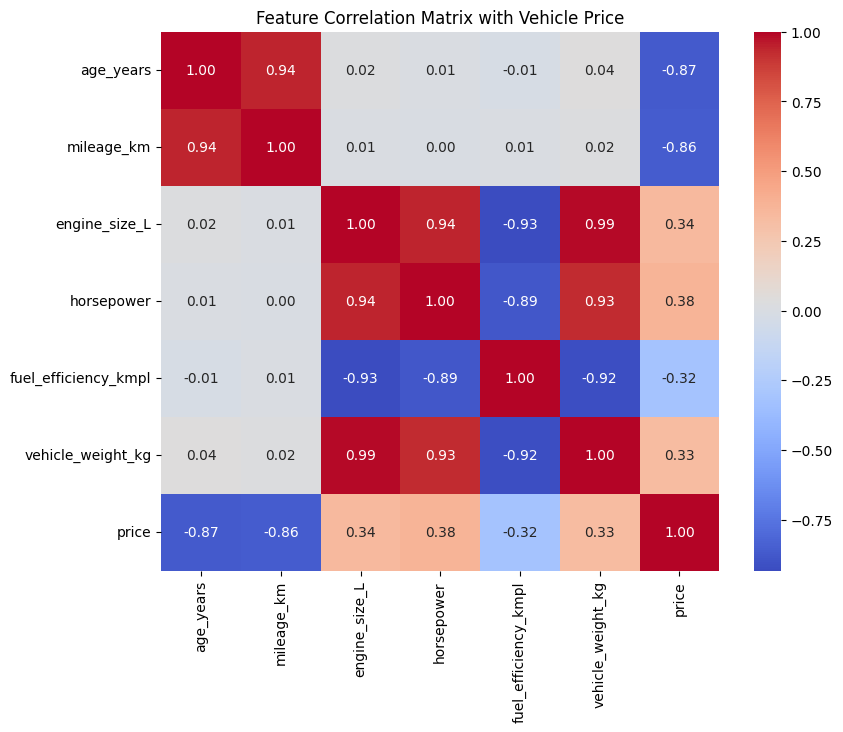

In [3]:
print("Descriptive Statistics:")
print(df.describe())

plt.figure(figsize=(9, 7))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix with Vehicle Price')
plt.show()

## 5. One-Hot Encoding & Train-Test Split
Encode categorical feature `brand` and split into 80/20 train-test sets.

In [4]:
df_encoded = pd.get_dummies(df, columns=['brand'], drop_first=False)

X = df_encoded.drop(columns=['price'])
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

print(f"Encoded Features Shape: {X.shape}")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

Encoded Features Shape: (600, 11)
X_train: (480, 11), X_test: (120, 11)


## 6. Model Training & Regression Evaluation
Train `RandomForestRegressor(n_estimators=300, random_state=42)` and evaluate MAE, RMSE, and $R^2$.

In [5]:
rf_model = RandomForestRegressor(n_estimators=300, random_state=SEED)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Random Forest Regressor Performance:")
print(f"  MAE:  ${mae:.2f}")
print(f"  RMSE: ${rmse:.2f}")
print(f"  R²:   {r2:.4f}")

Random Forest Regressor Performance:
  MAE:  $2051.48
  RMSE: $2690.46
  R²:   0.9662


## 7. Extract & Rank MDI Feature Importances
Extract tree-based Random Forest Mean Decrease in Impurity (MDI) `feature_importances_`.

In [6]:
importances = rf_model.feature_importances_
feature_names = X.columns

mdi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("--- RANDOM FOREST MEAN DECREASE IN IMPURITY (MDI) FEATURE IMPORTANCES ---")
print(mdi_df.to_string(index=False))

--- RANDOM FOREST MEAN DECREASE IN IMPURITY (MDI) FEATURE IMPORTANCES ---
             Feature  Importance
          mileage_km    0.406431
           age_years    0.387589
          horsepower    0.106626
           brand_BMW    0.037873
       engine_size_L    0.023365
   vehicle_weight_kg    0.021982
fuel_efficiency_kmpl    0.012192
       brand_Hyundai    0.001370
        brand_Toyota    0.001150
          brand_Ford    0.000799
         brand_Honda    0.000621


## 8. Compute Permutation Feature Importance
Compute test set `permutation_importance` by measuring performance drop when individual feature values are randomly shuffled.

In [7]:
perm_importance = permutation_importance(rf_model, X_test, y_test, n_repeats=10, random_state=SEED)

perm_df = pd.DataFrame({
    'Feature': feature_names,
    'Permutation_Importance_Mean': perm_importance.importances_mean,
    'Permutation_Importance_Std': perm_importance.importances_std
}).sort_values(by='Permutation_Importance_Mean', ascending=False).reset_index(drop=True)

print("\n--- PERMUTATION FEATURE IMPORTANCES (TEST SET) ---")
print(perm_df.to_string(index=False))


--- PERMUTATION FEATURE IMPORTANCES (TEST SET) ---
             Feature  Permutation_Importance_Mean  Permutation_Importance_Std
           age_years                     0.451727                    0.044417
          mileage_km                     0.385425                    0.039580
          horsepower                     0.115736                    0.009258
           brand_BMW                     0.088562                    0.006333
       engine_size_L                     0.005124                    0.001823
   vehicle_weight_kg                     0.004374                    0.001317
fuel_efficiency_kmpl                     0.001115                    0.000686
       brand_Hyundai                     0.000607                    0.000138
          brand_Ford                     0.000448                    0.000194
        brand_Toyota                     0.000371                    0.000196
         brand_Honda                     0.000085                    0.000128


## 9. Feature Importance Visualization
Plot horizontal bar charts comparing Random Forest Mean Decrease in Impurity (MDI) Feature Importance vs. Permutation Feature Importance.

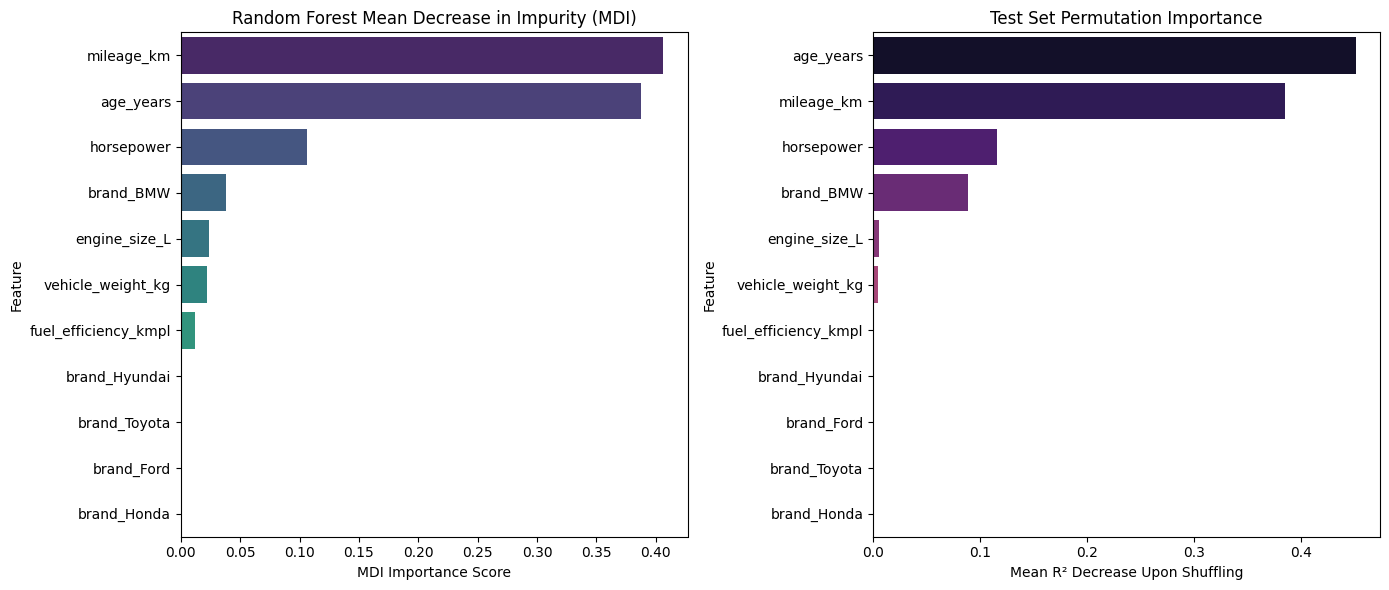

In [8]:
plt.figure(figsize=(14, 6))

# MDI Plot
plt.subplot(1, 2, 1)
sns.barplot(data=mdi_df, x='Importance', y='Feature', hue='Feature', legend=False, palette='viridis')
plt.title('Random Forest Mean Decrease in Impurity (MDI)')
plt.xlabel('MDI Importance Score')
plt.ylabel('Feature')

# Permutation Importance Plot
plt.subplot(1, 2, 2)
sns.barplot(data=perm_df, x='Permutation_Importance_Mean', y='Feature', hue='Feature', legend=False, palette='magma')
plt.title('Test Set Permutation Importance')
plt.xlabel('Mean R² Decrease Upon Shuffling')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

## 10. Key Insights & Interpretation
1. **MDI Contribution:** `age_years` and `mileage_km` contribute approximately **79% of total Mean Decrease in Impurity (MDI) feature importance** (40.64% mileage + 38.76% age).
2. **Secondary Drivers:** Engine power (`horsepower`) and premium brand classification (`brand_BMW`) provide secondary MDI contributions.
3. **MDI vs Permutation:** MDI measures node splitting impurity reduction across training trees, whereas Permutation importance measures actual performance decrease ($R^2$ drop) on unseen test data.
4. **Causation Disclaimer:** Feature importance reflects the model's learned feature dependence within this specific dataset and does **not** prove physical or market causation.